# 🤖 Pertemuan 12 — Python ML: Time Series Analysis
### Mata Kuliah: Python Machine Learning

---

## Tujuan Pembelajaran

Setelah pertemuan ini, kamu bisa:
1. Mengidentifikasi komponen timeseries: **trend**, **seasonality**, dan **residual**
2. Mendekomposisi data timeseries menggunakan `seasonal_decompose`
3. Menguji stasioneritas data dengan **ADF Test** dan melakukan differencing
4. Membangun model **ARIMA**, **SARIMA**, dan **Auto-ARIMA** untuk forecasting
5. Mengaplikasikan **Random Forest** dan **XGBoost** pada timeseries dengan feature engineering lag
6. Membandingkan performa keempat model secara visual dan kuantitatif

---

## Recap Cepat — Quiz Kilat ⚡

Sebelum mulai, jawab pertanyaan berikut tanpa melihat catatan:

1. Apa perbedaan **supervised** dan **unsupervised learning**? Termasuk yang mana clustering?
2. Dari pertemuan lalu: sebutkan 3 algoritma clustering yang kita pelajari dan kapan masing-masing cocok digunakan!
3. Apa itu **Silhouette Score**? Nilai berapa yang dianggap cluster yang baik?

---

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statsmodels — dekomposisi, ADF test, ARIMA/SARIMA
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Auto-ARIMA — otomatis pilih parameter terbaik
try:
    from pmdarima import auto_arima
    print("✅ pmdarima tersedia")
except ImportError:
    print("❌ pmdarima belum terinstall. Jalankan: pip install pmdarima")

# ML models
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# XGBoost
try:
    from xgboost import XGBRegressor
    print("✅ xgboost tersedia")
except ImportError:
    print("❌ xgboost belum terinstall. Jalankan: pip install xgboost")

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print("✅ Setup selesai!")

✅ pmdarima tersedia
✅ xgboost tersedia
✅ Setup selesai!


---

## BAGIAN 1: Apa itu Time Series?

**Time Series** adalah urutan titik data yang diukur secara berurutan dalam **interval waktu yang sama** — harian, bulanan, tahunan, dll.

```
Contoh data timeseries:

  Penumpang │ ●                              ●
  Pesawat   │       ●          ●
            │   ●      ●   ●      ●
            │                         ●
            └──────────────────────────────────→ Waktu
              Jan  Feb  Mar  Apr  Mei  Jun  Jul
```

**Apa yang membedakan timeseries dari data biasa?**

| Data Biasa | Data Timeseries |
|-----------|-----------------|
| Baris independen satu sama lain | Urutan waktu PENTING — baris ke-t bergantung pada t-1 |
| Bisa di-shuffle tanpa masalah | Tidak boleh di-shuffle — merusak pola waktu |
| Train/test split acak | Train/test split **harus temporal** (masa lalu → masa depan) |

---

### Komponen Timeseries

Sebuah data timeseries umumnya terdiri dari 3 komponen:

```
DATA = TREND + SEASONALITY + RESIDUAL

  Trend:       ─────────────────────────/   (arah jangka panjang)
  Seasonality:       ∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿    (pola berulang periodik)
  Residual:          |||||||||||||||||||    (noise / variasi acak)
```

| Komponen | Deskripsi | Contoh |
|----------|-----------|--------|
| **Trend** | Arah umum jangka panjang (naik/turun/datar) | Pertumbuhan pengguna internet selama 20 tahun |
| **Seasonality** | Pola yang berulang dalam periode tetap | Penjualan tinggi setiap Desember |
| **Residual** | Variasi yang tidak dapat dijelaskan oleh trend atau seasonality | Gangguan acak, event tak terduga |

---

### Additive vs Multiplicative Decomposition

```
Additive:      Y(t) = Trend + Seasonality + Residual
               → Amplitudo seasonality TETAP sepanjang waktu
               → Cocok untuk data yang variansinya stabil

Multiplicative: Y(t) = Trend × Seasonality × Residual
               → Amplitudo seasonality MEMBESAR seiring trend naik
               → Cocok untuk data ekonomi/bisnis yang tumbuh

  Additive:          Multiplicative:
  ∿∿∿∿∿∿∿∿∿∿         ∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿∿
  (tinggi sama)      (makin tinggi seiring waktu)
```

---

## BAGIAN 2: Load Data — AirPassengers

Kita gunakan dataset **AirPassengers** — dataset klasik berisi jumlah penumpang pesawat internasional dari tahun 1949 hingga 1960 (data bulanan).

Dataset ini ideal untuk belajar timeseries karena:
- Memiliki **trend naik** yang jelas (penerbangan komersial makin populer)
- Memiliki **seasonality bulanan** yang kuat (liburan musim panas = puncak)
- Amplitudo seasonality **membesar seiring waktu** → contoh multiplicative
- Tersedia langsung di statsmodels

| Informasi | Detail |
|-----------|--------|
| Periode | Januari 1949 — Desember 1960 |
| Frekuensi | Bulanan |
| Jumlah data | 144 titik |
| Target | Jumlah penumpang (ribuan) |

In [2]:
# Load AirPassengers dari statsmodels
# get_rdataset mengambil dari R datasets — memerlukan koneksi internet pada run pertama
df_raw = sm.datasets.get_rdataset("AirPassengers", "datasets").data

# Buat DatetimeIndex bulanan yang proper
df = pd.DataFrame(
    {'passengers': df_raw['value'].values},
    index=pd.date_range('1949-01', periods=len(df_raw), freq='MS')
)

print(f"✅ Dataset berhasil dimuat!")
print(f"\nShape   : {df.shape}")
print(f"Periode   : {df.index[0].strftime('%B %Y')} → {df.index[-1].strftime('%B %Y')}")
print(f"Frekuensi : Bulanan")
print(f"\nStatistik deskriptif:")
print(df.describe().round(2))
print(f"\n5 baris pertama:")
df.head()

✅ Dataset berhasil dimuat!

Shape   : (144, 1)
Periode   : January 1949 → December 1960
Frekuensi : Bulanan

Statistik deskriptif:
       passengers
count      144.00
mean       280.30
std        119.97
min        104.00
25%        180.00
50%        265.50
75%        360.50
max        622.00

5 baris pertama:


,passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


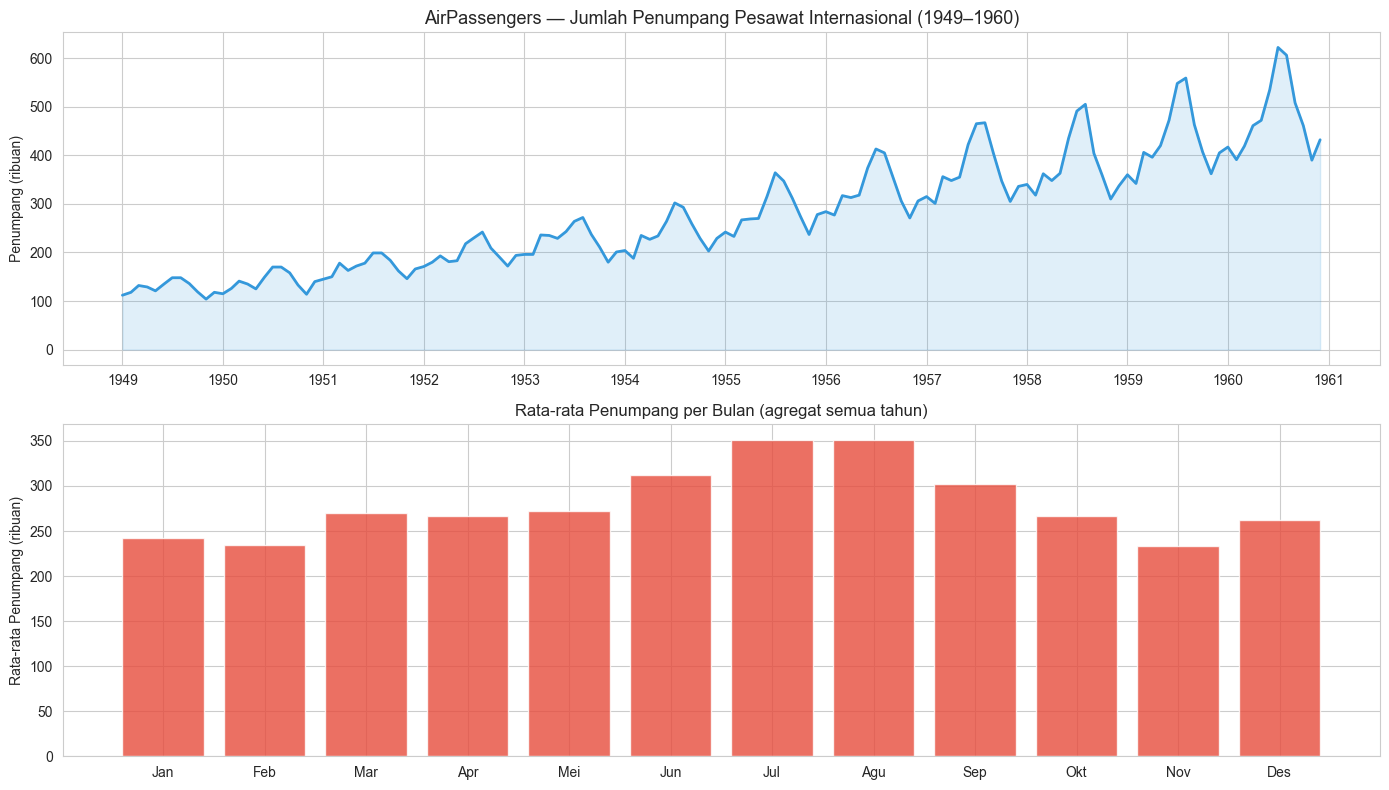


💡 Pengamatan:
   - Ada trend naik yang jelas dari 1949 hingga 1960
   - Ada pola musiman: puncak di Juli–Agustus (liburan musim panas)
   - Amplitudo fluktuasi makin besar seiring waktu → kemungkinan multiplicative


In [3]:
# Visualisasi awal — plot deret waktu lengkap
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot utama
axes[0].plot(df.index, df['passengers'], color='#3498db', linewidth=2)
axes[0].fill_between(df.index, df['passengers'], alpha=0.15, color='#3498db')
axes[0].set_title('AirPassengers — Jumlah Penumpang Pesawat Internasional (1949–1960)', fontsize=13)
axes[0].set_ylabel('Penumpang (ribuan)')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Rata-rata per bulan (musiman)
df['month'] = df.index.month
rata_per_bulan = df.groupby('month')['passengers'].mean()
nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

axes[1].bar(range(1, 13), rata_per_bulan.values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nama_bulan)
axes[1].set_title('Rata-rata Penumpang per Bulan (agregat semua tahun)', fontsize=12)
axes[1].set_ylabel('Rata-rata Penumpang (ribuan)')

df.drop(columns='month', inplace=True)

plt.tight_layout()
plt.show()

print("\n💡 Pengamatan:")
print("   - Ada trend naik yang jelas dari 1949 hingga 1960")
print("   - Ada pola musiman: puncak di Juli–Agustus (liburan musim panas)")
print("   - Amplitudo fluktuasi makin besar seiring waktu → kemungkinan multiplicative")

---

## BAGIAN 3: Dekomposisi Timeseries

`seasonal_decompose` dari statsmodels memecah deret waktu menjadi 3 komponen: **trend**, **seasonality**, dan **residual**.

```
Input: deret waktu asli
         ↓
seasonal_decompose(model='multiplicative', period=12)
         ↓
  ┌─────────────┬──────────────────┬──────────────┐
  │   Observed  │      Trend       │  Seasonal    │  Residual
  │  (asli)     │  (moving avg)    │  (pola ulang)│  (sisa)
  └─────────────┴──────────────────┴──────────────┘
```

**Parameter `model`:**
- `'additive'` → Y = T + S + R (variansi musiman stabil)
- `'multiplicative'` → Y = T × S × R (variansi musiman tumbuh bersama trend)

**Parameter `period`:**
- Jumlah titik dalam satu siklus musiman
- Data bulanan dengan musim tahunan → `period=12`

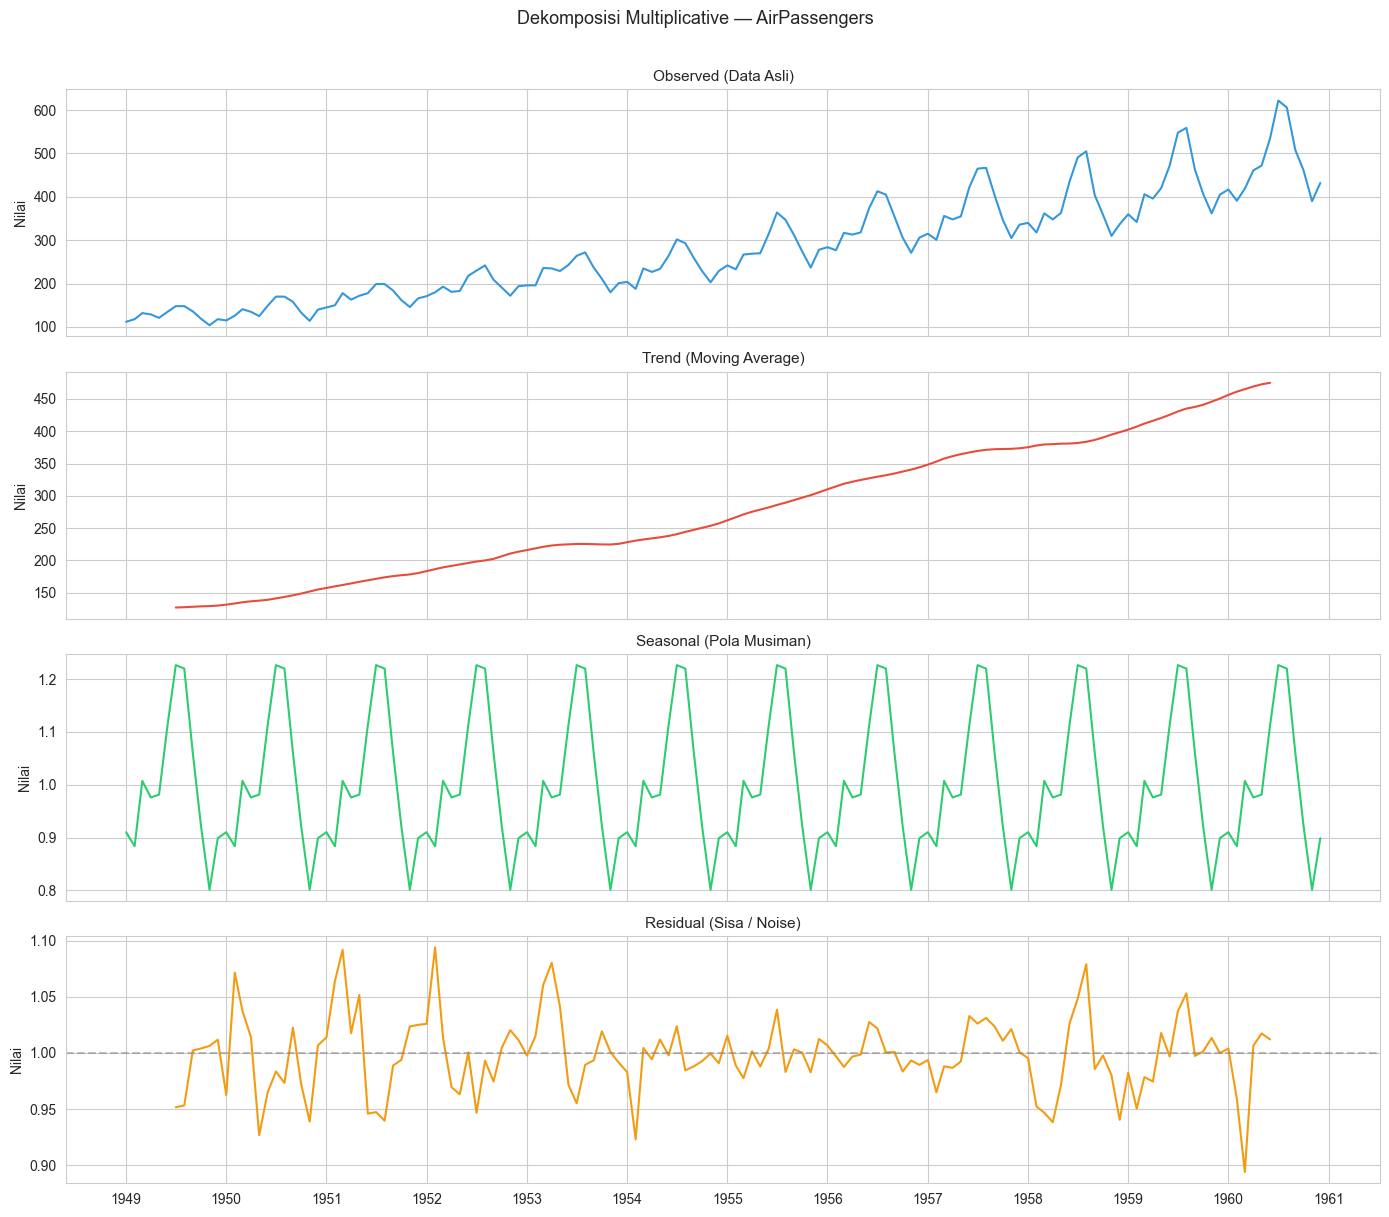


💡 Interpretasi:
   Trend  : Naik konsisten dari ~115 (1949) hingga ~430 (1960)
   Seasonal: Faktor pengali — bulan Juli sekitar 1.3× rata-rata (30% di atas normal)
   Residual: Mendekati 1.0 → dekomposisi berhasil menjelaskan sebagian besar variasi


In [4]:
# Dekomposisi Multiplicative (cocok untuk AirPassengers)
decomp_mul = seasonal_decompose(df['passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
warna = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
komponen = [
    (decomp_mul.observed,  'Observed (Data Asli)'),
    (decomp_mul.trend,     'Trend (Moving Average)'),
    (decomp_mul.seasonal,  'Seasonal (Pola Musiman)'),
    (decomp_mul.resid,     'Residual (Sisa / Noise)'),
]

for ax, (data, judul), wrn in zip(axes, komponen, warna):
    ax.plot(data.index, data, color=wrn, linewidth=1.5)
    ax.set_title(judul, fontsize=11)
    ax.set_ylabel('Nilai')
    if judul.startswith('Residual'):
        ax.axhline(1, color='gray', linestyle='--', alpha=0.5)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Dekomposisi Multiplicative — AirPassengers', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Interpretasi:")
print("   Trend  : Naik konsisten dari ~115 (1949) hingga ~430 (1960)")
print("   Seasonal: Faktor pengali — bulan Juli sekitar 1.3× rata-rata (30% di atas normal)")
print("   Residual: Mendekati 1.0 → dekomposisi berhasil menjelaskan sebagian besar variasi")

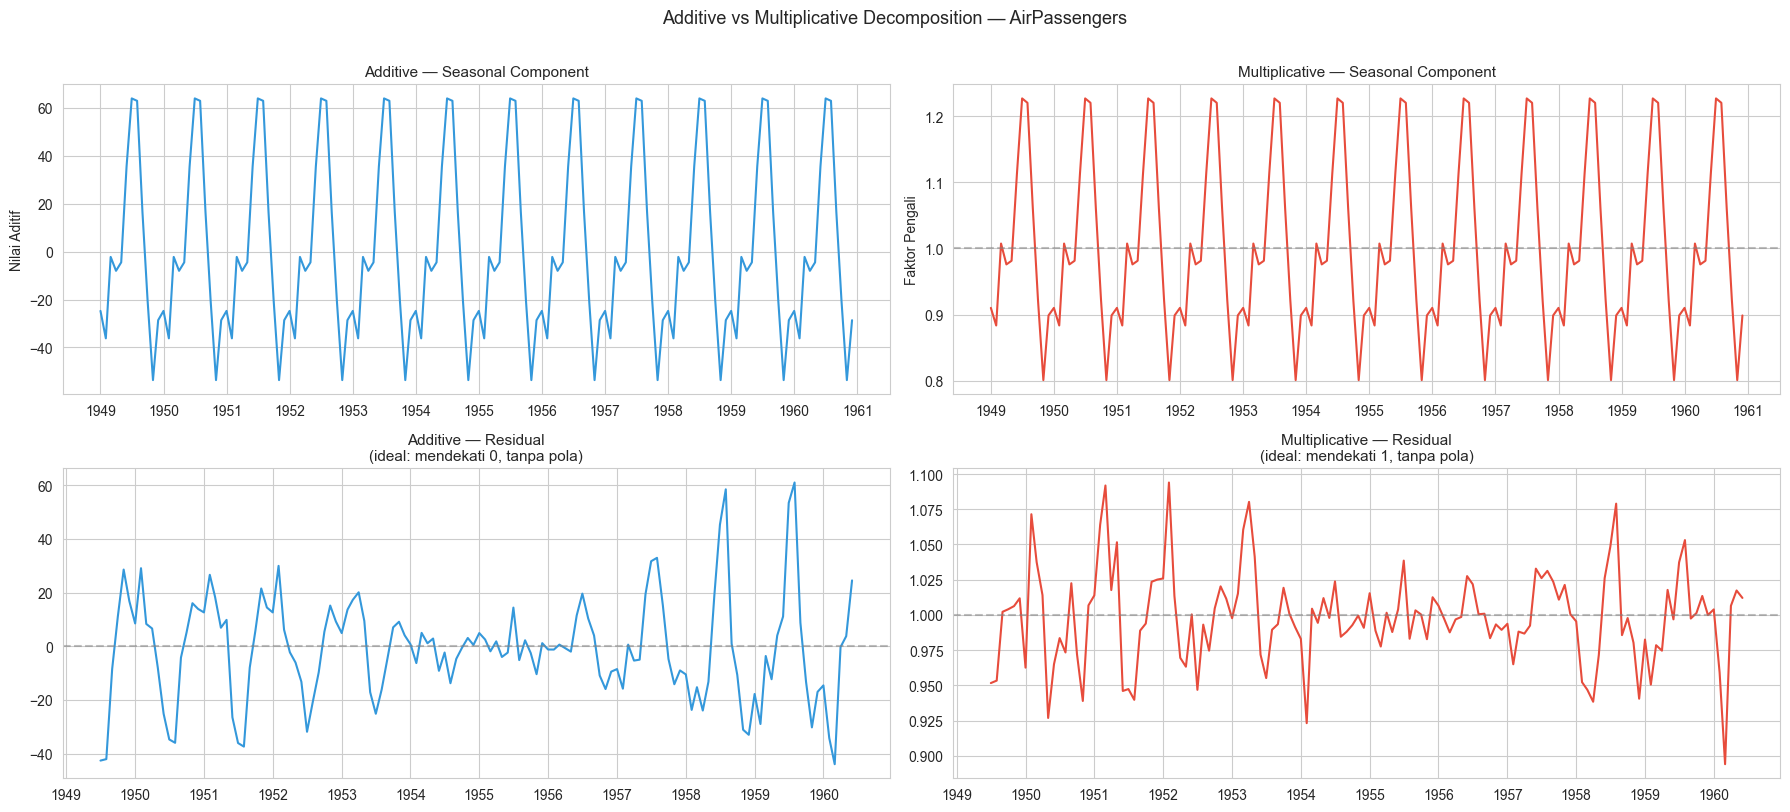


📌 Kesimpulan: Multiplicative lebih cocok untuk AirPassengers karena:
   - Faktor seasonal stabil di sekitar 1 (tidak membesar/mengecil secara sistematis)
   - Residual multiplicative lebih 'bersih' dari pola dibanding additive


In [5]:
# Bandingkan: Additive vs Multiplicative
decomp_add = seasonal_decompose(df['passengers'], model='additive', period=12)

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# Komponen Seasonal dari keduanya
axes[0, 0].plot(decomp_add.seasonal, color='#3498db', linewidth=1.5)
axes[0, 0].set_title('Additive — Seasonal Component', fontsize=11)
axes[0, 0].set_ylabel('Nilai Aditif')

axes[0, 1].plot(decomp_mul.seasonal, color='#e74c3c', linewidth=1.5)
axes[0, 1].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Multiplicative — Seasonal Component', fontsize=11)
axes[0, 1].set_ylabel('Faktor Pengali')

# Residual dari keduanya
axes[1, 0].plot(decomp_add.resid, color='#3498db', linewidth=1.5)
axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Additive — Residual\n(ideal: mendekati 0, tanpa pola)', fontsize=11)

axes[1, 1].plot(decomp_mul.resid, color='#e74c3c', linewidth=1.5)
axes[1, 1].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Multiplicative — Residual\n(ideal: mendekati 1, tanpa pola)', fontsize=11)

for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Additive vs Multiplicative Decomposition — AirPassengers', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n📌 Kesimpulan: Multiplicative lebih cocok untuk AirPassengers karena:")
print("   - Faktor seasonal stabil di sekitar 1 (tidak membesar/mengecil secara sistematis)")
print("   - Residual multiplicative lebih 'bersih' dari pola dibanding additive")

---

## BAGIAN 4: Stasioneritas & ADF Test

### Apa itu Stasioneritas?

Model klasik seperti ARIMA **mengasumsikan data stasioner** — yaitu data yang statistiknya (mean, variansi) **tidak berubah seiring waktu**.

```
Non-Stasioner (ARIMA tidak bisa langsung):    Stasioner (siap untuk ARIMA):
                                              
  Nilai                                         Nilai
  ↑  /                                          ↑ ─ ─ ─ ─ mean stabil
  | /   → trend naik                            |∿∿∿∿∿∿∿∿∿∿
  |/                                            |
  └────────→ Waktu                              └────────→ Waktu
```

**Cara membuat data stasioner:**
1. **Differencing** — kurangi nilai saat ini dengan nilai sebelumnya: `Δy(t) = y(t) − y(t−1)`
2. **Log transform** — kurangi efek variansi yang tumbuh: `log(y(t))`
3. **Seasonal differencing** — diferensiasi antar periode yang sama: `Δ₁₂y(t) = y(t) − y(t−12)`

---

### ADF Test (Augmented Dickey-Fuller)

**ADF Test** adalah uji statistik untuk memeriksa stasioneritas.

```
Hipotesis:
  H₀: Data TIDAK stasioner (ada unit root)
  H₁: Data STASIONER (tidak ada unit root)

Keputusan:
  p-value ≤ 0.05 → Tolak H₀ → DATA STASIONER ✅
  p-value >  0.05 → Gagal tolak H₀ → DATA TIDAK STASIONER ❌
                    → Perlu differencing, coba lagi
```

In [6]:
def uji_adf(series, nama=""):
    """Jalankan ADF test dan tampilkan hasilnya secara ringkas."""
    hasil = adfuller(series.dropna())
    adf_stat, p_val, lags, n_obs, critical, _ = hasil
    stasioner = p_val <= 0.05
    status = "✅ STASIONER" if stasioner else "❌ TIDAK STASIONER"
    print(f"{'─'*55}")
    print(f"ADF Test — {nama}")
    print(f"{'─'*55}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_val:.6f}")
    print(f"  Critical (5%) : {critical['5%']:.4f}")
    print(f"  Kesimpulan    : {status}")
    print(f"{'─'*55}")
    return stasioner

# Uji data asli
print("=" * 55)
print("LANGKAH 1: Uji data asli")
uji_adf(df['passengers'], "Data Asli (passengers)")

LANGKAH 1: Uji data asli
───────────────────────────────────────────────────────
ADF Test — Data Asli (passengers)
───────────────────────────────────────────────────────
  ADF Statistic : 0.8154
  p-value       : 0.991880
  Critical (5%) : -2.8840
  Kesimpulan    : ❌ TIDAK STASIONER
───────────────────────────────────────────────────────


np.False_

In [7]:
# Transformasi log untuk menstabilkan variansi
df['log_passengers'] = np.log(df['passengers'])

# Differencing: regular (d=1) dan seasonal (D=1, s=12)
df['diff1']          = df['log_passengers'].diff(1)        # hilangkan trend
df['diff1_diff12']   = df['diff1'].diff(12)                # hilangkan seasonality

print("LANGKAH 2: Log transform")
uji_adf(df['log_passengers'], "Log(passengers)")

print("\nLANGKAH 3: Log + First Difference (d=1)")
uji_adf(df['diff1'], "Log-diff1")

print("\nLANGKAH 4: Log + First Diff + Seasonal Diff (d=1, D=1, s=12)")
uji_adf(df['diff1_diff12'], "Log-diff1-diff12")

LANGKAH 2: Log transform
───────────────────────────────────────────────────────
ADF Test — Log(passengers)
───────────────────────────────────────────────────────
  ADF Statistic : -1.7170
  p-value       : 0.422367
  Critical (5%) : -2.8840
  Kesimpulan    : ❌ TIDAK STASIONER
───────────────────────────────────────────────────────

LANGKAH 3: Log + First Difference (d=1)
───────────────────────────────────────────────────────
ADF Test — Log-diff1
───────────────────────────────────────────────────────
  ADF Statistic : -2.7171
  p-value       : 0.071121
  Critical (5%) : -2.8844
  Kesimpulan    : ❌ TIDAK STASIONER
───────────────────────────────────────────────────────

LANGKAH 4: Log + First Diff + Seasonal Diff (d=1, D=1, s=12)
───────────────────────────────────────────────────────
ADF Test — Log-diff1-diff12
───────────────────────────────────────────────────────
  ADF Statistic : -4.4433
  p-value       : 0.000249
  Critical (5%) : -2.8864
  Kesimpulan    : ✅ STASIONER
─────────

np.True_

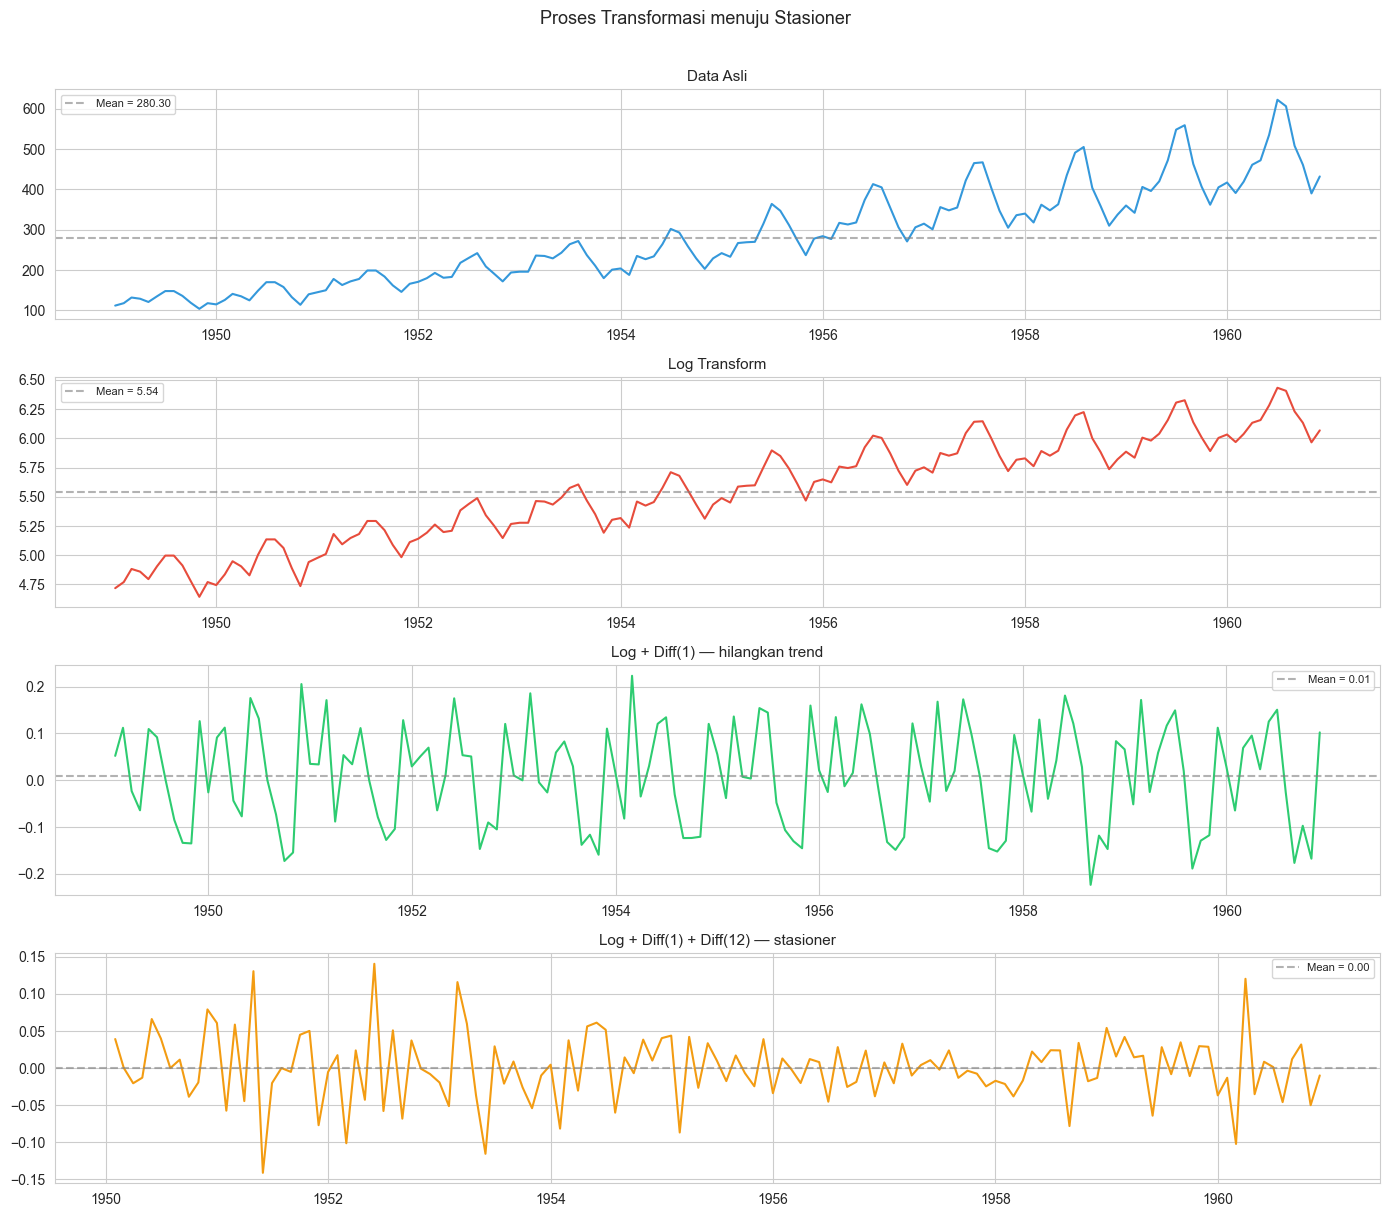


💡 Setelah log + diff(1) + diff(12), mean stabil di sekitar 0 → STASIONER


In [8]:
# Visualisasi proses differencing
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

series_plot = [
    (df['passengers'],      'Data Asli',                   '#3498db'),
    (df['log_passengers'],  'Log Transform',                '#e74c3c'),
    (df['diff1'],           'Log + Diff(1) — hilangkan trend',      '#2ecc71'),
    (df['diff1_diff12'],    'Log + Diff(1) + Diff(12) — stasioner', '#f39c12'),
]

for ax, (s, judul, wrn) in zip(axes, series_plot):
    ax.plot(s.dropna(), color=wrn, linewidth=1.5)
    ax.set_title(judul, fontsize=11)
    ax.axhline(s.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Mean = {s.mean():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Proses Transformasi menuju Stasioner', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Setelah log + diff(1) + diff(12), mean stabil di sekitar 0 → STASIONER")

---

## BAGIAN 5: ARIMA & SARIMA

### ARIMA — Konsep

**ARIMA** = *AutoRegressive Integrated Moving Average*

ARIMA adalah model statistik klasik untuk forecasting timeseries stasioner. Ia punya 3 parameter `(p, d, q)`:

```
ARIMA(p, d, q):

  p = AutoRegressive order:
      "Berapa lag nilai masa lalu yang digunakan?"
      AR(2) → y(t) = c + φ₁·y(t-1) + φ₂·y(t-2) + ε(t)

  d = Differencing order:
      "Berapa kali didiferensiasi agar stasioner?"
      d=1 → diff satu kali (hilangkan trend linear)

  q = Moving Average order:
      "Berapa lag error (residual) masa lalu yang digunakan?"
      MA(1) → y(t) = c + ε(t) + θ₁·ε(t-1)
```

### SARIMA — Ekstensi Seasonal

**SARIMA** = *Seasonal ARIMA* → ARIMA + komponen seasonal

Notasi: `SARIMA(p, d, q)(P, D, Q, s)`

```
(p, d, q) = komponen non-seasonal (sama seperti ARIMA)
(P, D, Q) = komponen seasonal (AR, I, MA untuk pola berulang)
s         = periode seasonal (s=12 untuk data bulanan tahunan)

Contoh: SARIMA(1, 1, 1)(0, 1, 1, 12)
        → non-seasonal: AR(1), diff 1x, MA(1)
        → seasonal    : tanpa AR seasonal, diff seasonal 1x, MA seasonal(1)
                        dengan periode 12 bulan
```

### Cara Menentukan p dan q — ACF & PACF

**ACF** (Autocorrelation Function) dan **PACF** (Partial Autocorrelation Function) membantu menentukan parameter:

```
ACF:                           PACF:
  Lag  │ █                       Lag  │ █
    1  │ ████                      1  │ ████████
    2  │ ████                      2  │ █
    3  │ ███                       3  │
    4  │ ██                        4  │
       └──────                        └──────
  → Menurun perlahan             → Cutoff di lag 1
    → indikasi AR                → MA(1) mungkin cocok
```

| Pola | Interpretasi |
|------|-------------|
| ACF turun eksponensial, PACF cutoff di lag p | → AR(p) |
| PACF turun eksponensial, ACF cutoff di lag q | → MA(q) |
| Keduanya turun perlahan | → ARMA(p, q) |

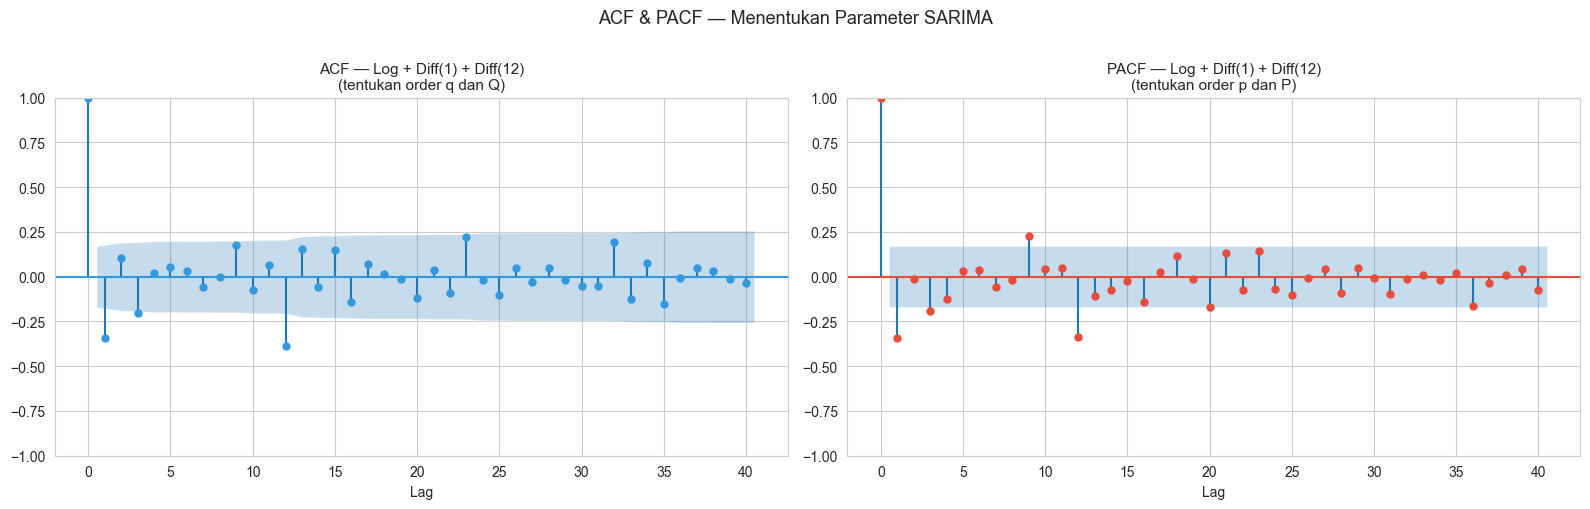


💡 Cara baca:
   - Spike signifikan di ACF lag 1  → MA(1), q=1
   - Spike signifikan di ACF lag 12 → MA seasonal(1), Q=1
   - PACF cutoff setelah lag 1      → AR(1), p=1
   → Kandidat model: SARIMA(1,1,1)(0,1,1,12)


In [9]:
# Plot ACF dan PACF pada data yang sudah stasioner
seri_stasioner = df['diff1_diff12'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(seri_stasioner, lags=40, ax=axes[0], color='#3498db', alpha=0.05)
axes[0].set_title('ACF — Log + Diff(1) + Diff(12)\n(tentukan order q dan Q)', fontsize=11)
axes[0].set_xlabel('Lag')

plot_pacf(seri_stasioner, lags=40, ax=axes[1], color='#e74c3c', alpha=0.05, method='ywm')
axes[1].set_title('PACF — Log + Diff(1) + Diff(12)\n(tentukan order p dan P)', fontsize=11)
axes[1].set_xlabel('Lag')

plt.suptitle('ACF & PACF — Menentukan Parameter SARIMA', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Cara baca:")
print("   - Spike signifikan di ACF lag 1  → MA(1), q=1")
print("   - Spike signifikan di ACF lag 12 → MA seasonal(1), Q=1")
print("   - PACF cutoff setelah lag 1      → AR(1), p=1")
print("   → Kandidat model: SARIMA(1,1,1)(0,1,1,12)")

Training set : Jan 1949 → Dec 1958  (120 bulan)
Test set     : Jan 1959  → Dec 1960  (24 bulan)


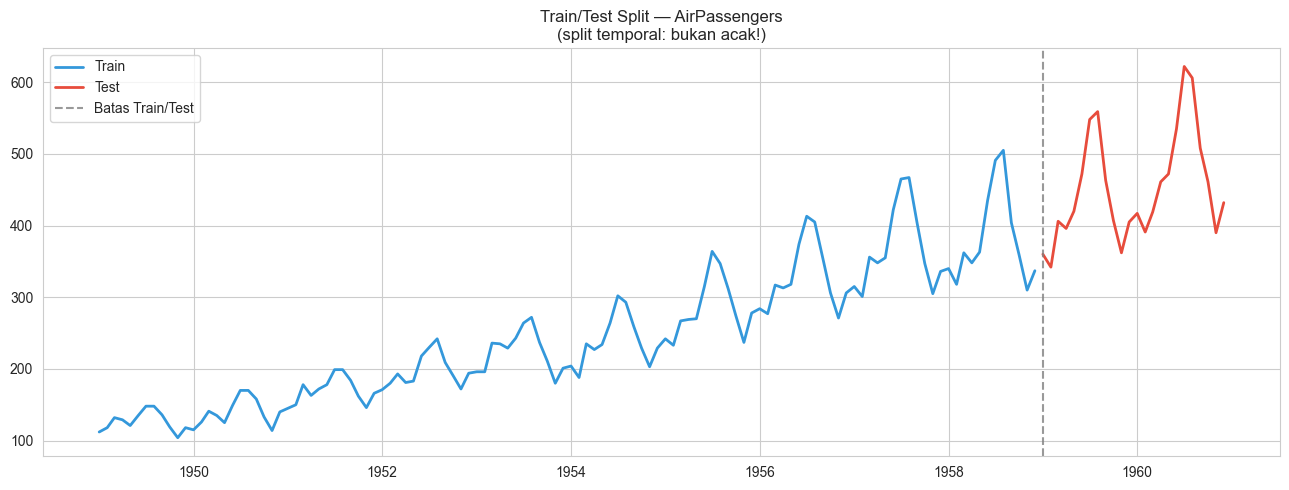


✅ Helper function plot_forecast() siap digunakan


In [10]:
# Train/test split — temporal (HARUS urutkan berdasarkan waktu)
# 80% train (1949–1957), 20% test (1958–1960)
n_test = 24  # 2 tahun terakhir sebagai test
seri   = df['passengers']

train = seri.iloc[:-n_test]
test  = seri.iloc[-n_test:]

print(f"Training set : {train.index[0].strftime('%b %Y')} → {train.index[-1].strftime('%b %Y')}  ({len(train)} bulan)")
print(f"Test set     : {test.index[0].strftime('%b %Y')}  → {test.index[-1].strftime('%b %Y')}  ({len(test)} bulan)")

# Visualisasi split
plt.figure(figsize=(13, 5))
plt.plot(train, label='Train', color='#3498db', linewidth=2)
plt.plot(test,  label='Test',  color='#e74c3c', linewidth=2)
plt.axvline(test.index[0], color='gray', linestyle='--', alpha=0.8, label='Batas Train/Test')
plt.title('Train/Test Split — AirPassengers\n(split temporal: bukan acak!)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ── Helper function: plot forecast vs actual ────────────────────────────────
def plot_forecast(train, test, forecast, model_name, color, ci=None):
    """
    Plot hasil forecast vs data aktual untuk satu model.
    Menampilkan 24 bulan terakhir train + seluruh periode test.
    """
    mape = np.mean(np.abs((test.values - np.array(forecast)) / test.values)) * 100

    plt.figure(figsize=(13, 5))
    plt.plot(train.iloc[-24:], label='Train (24 bln terakhir)',
             color='#3498db', linewidth=1.5, alpha=0.7)
    plt.plot(test, label='Aktual (Test)',
             color='black', linewidth=2.5)
    plt.plot(pd.Series(np.array(forecast), index=test.index),
             label=f'Forecast — MAPE {mape:.2f}%',
             color=color, linewidth=2, linestyle='--')
    if ci is not None:
        plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                         alpha=0.15, color=color, label='CI 95%')
    plt.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7)
    plt.title(f'{model_name} — Forecast vs Aktual', fontsize=12)
    plt.ylabel('Penumpang (ribuan)')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    return mape

print("\n✅ Helper function plot_forecast() siap digunakan")

Melatih ARIMA(1,1,1)...
AIC: 1125.43  |  BIC: 1133.77


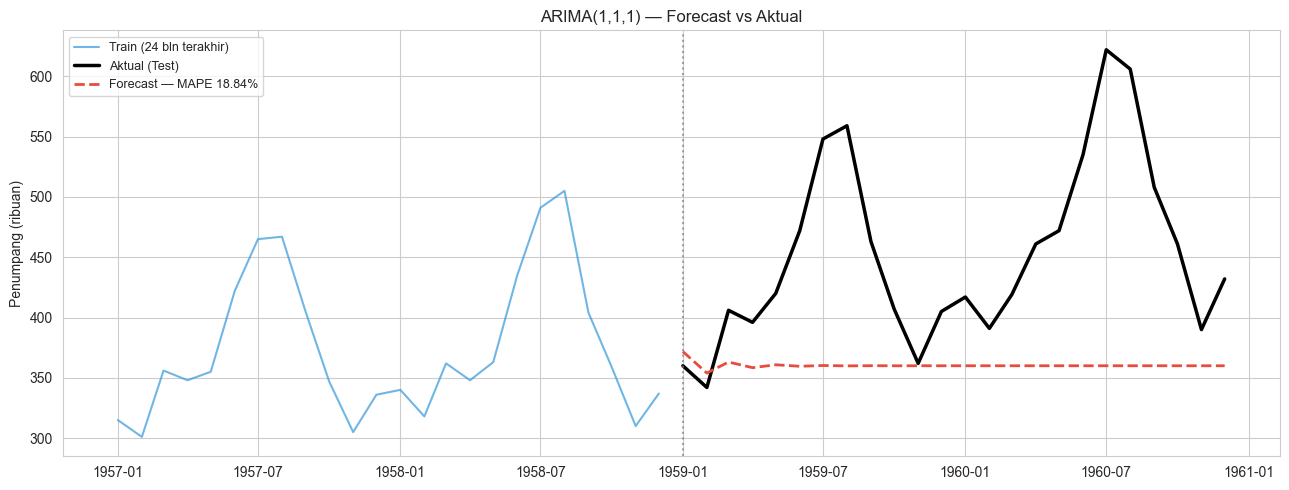

MAPE ARIMA : 18.84%


In [11]:
# ── Model 1: ARIMA(1,1,1) ────────────────────────────────────────────────────
print("Melatih ARIMA(1,1,1)...")
model_arima  = ARIMA(train, order=(1, 1, 1))
hasil_arima  = model_arima.fit()
fc_arima     = hasil_arima.forecast(steps=n_test)

print(f"AIC: {hasil_arima.aic:.2f}  |  BIC: {hasil_arima.bic:.2f}")

mape_arima = plot_forecast(train, test, fc_arima,
                           'ARIMA(1,1,1)', '#e74c3c')
print(f"MAPE ARIMA : {mape_arima:.2f}%")

Melatih SARIMA(1,1,1)(1,1,1,12)...
AIC: 707.72  |  BIC: 720.38


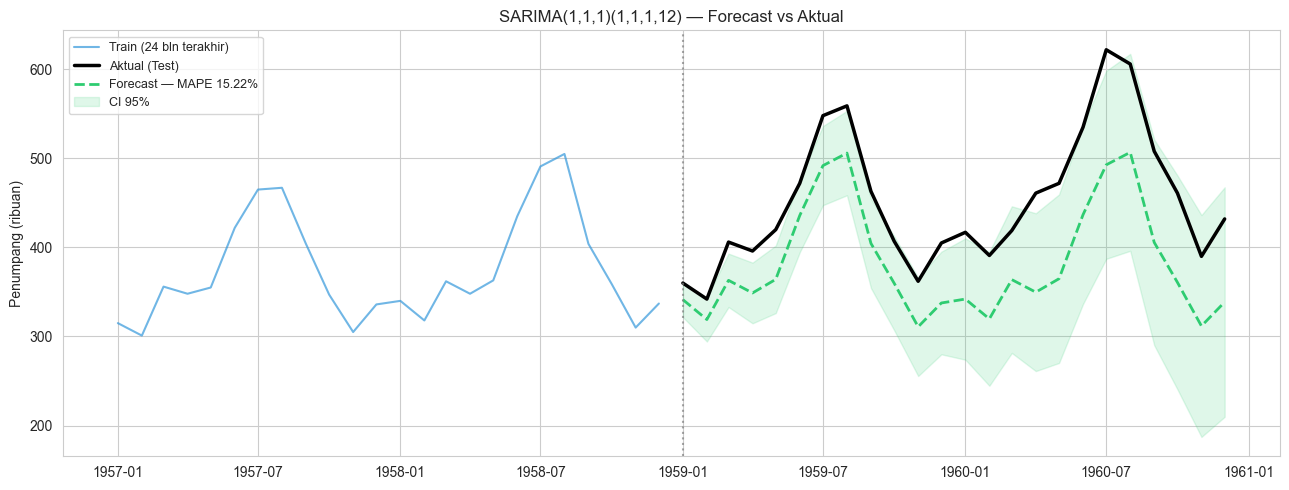

MAPE SARIMA: 15.22%


In [12]:
# ── Model 2: SARIMA(1,1,1)(0,1,1,12) ────────────────────────────────────────
print("Melatih SARIMA(1,1,1)(1,1,1,12)...")
model_sarima = SARIMAX(train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
hasil_sarima = model_sarima.fit(disp=False)

fc_sarima_obj = hasil_sarima.get_forecast(steps=n_test)
fc_sarima     = fc_sarima_obj.predicted_mean
ci_sarima     = fc_sarima_obj.conf_int(alpha=0.05)

print(f"AIC: {hasil_sarima.aic:.2f}  |  BIC: {hasil_sarima.bic:.2f}")

mape_sarima = plot_forecast(train, test, fc_sarima,
                            'SARIMA(1,1,1)(1,1,1,12)', '#2ecc71',
                            ci=ci_sarima)
print(f"MAPE SARIMA: {mape_sarima:.2f}%")

---

### Auto-ARIMA — Parameter Otomatis

Memilih `p, d, q, P, D, Q` secara manual (via ACF/PACF) memerlukan keahlian. **Auto-ARIMA** dari library `pmdarima` melakukan pencarian otomatis menggunakan kriteria AIC/BIC.

```
Manual ARIMA:                     Auto-ARIMA:
────────────────────────          ────────────────────────
1. Plot ACF & PACF                auto_arima(train,
2. Tebak p, q                       seasonal=True, m=12,
3. Coba ARIMA(p,d,q)                stepwise=True,
4. Cek AIC                          information_criterion='aic')
5. Coba kombinasi lain                    ↓
6. Pilih yang terbaik             Otomatis coba berbagai (p,d,q)(P,D,Q)
                                  → pilih yang AIC-nya paling rendah ✅
```

**Parameter penting:**
- `seasonal=True, m=12` → aktifkan pencarian komponen seasonal
- `stepwise=True` → cari dengan algoritma stepwise (lebih cepat dari brute-force)
- `information_criterion='aic'` → gunakan AIC sebagai kriteria pemilihan

Mencari parameter optimal dengan Auto-ARIMA (harap tunggu ~30 detik)...

✅ Parameter terpilih: (2, 0, 0) x (0, 1, 0, 12)
   AIC : 808.86

Ringkasan model:
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  120
Model:             SARIMAX(2, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -400.431
Date:                            Sat, 06 Jun 2026   AIC                            808.863
Time:                                    15:26:00   BIC                            819.592
Sample:                                01-01-1949   HQIC                           813.213
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         


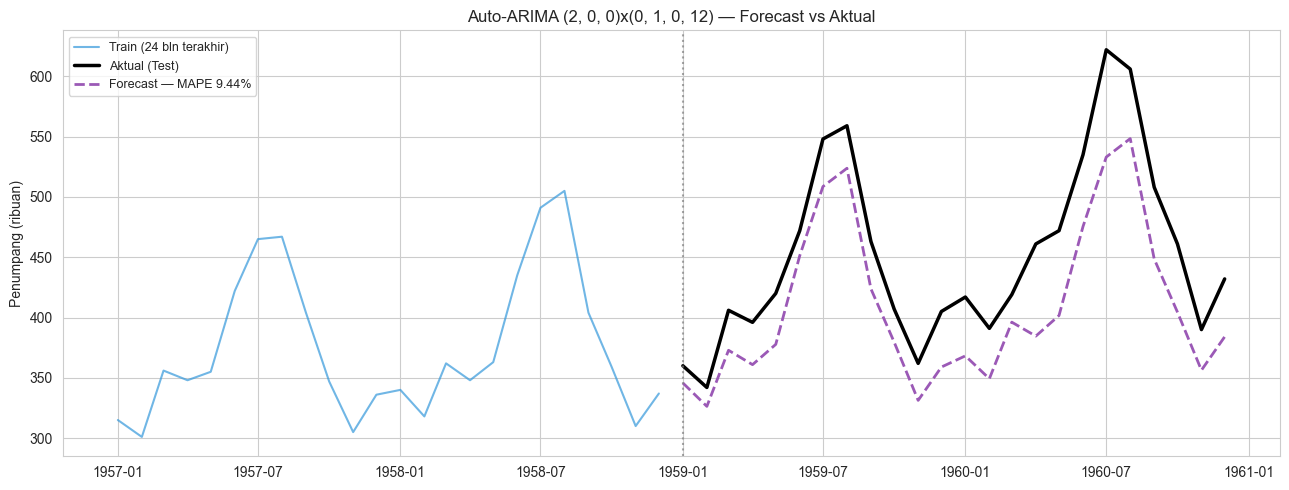

MAPE Auto-ARIMA: 9.44%


In [13]:
# ── Model 3: Auto-ARIMA ──────────────────────────────────────────────────────
print("Mencari parameter optimal dengan Auto-ARIMA (harap tunggu ~30 detik)...")

model_auto = auto_arima(
    train,
    seasonal=True,
    m=12,                        # periode seasonal bulanan
    stepwise=True,               # stepwise search (lebih cepat)
    information_criterion='aic', # pilih berdasarkan AIC terkecil
    suppress_warnings=True,
    error_action='ignore',
)

print(f"\n✅ Parameter terpilih: {model_auto.order} x {model_auto.seasonal_order}")
print(f"   AIC : {model_auto.aic():.2f}")
print(f"\nRingkasan model:")
print(model_auto.summary().tables[0])

# Forecast
fc_auto = model_auto.predict(n_periods=n_test)

mape_auto = plot_forecast(train, test, fc_auto,
                          f'Auto-ARIMA {model_auto.order}x{model_auto.seasonal_order}',
                          '#9b59b6')
print(f"MAPE Auto-ARIMA: {mape_auto:.2f}%")

---

## BAGIAN 6: ML untuk Timeseries — Random Forest & XGBoost

Model ML seperti **Random Forest** dan **XGBoost** tidak memahami urutan waktu secara otomatis. Kita perlu mengubah data timeseries menjadi format tabel dengan **fitur lag** — nilai dari periode sebelumnya.

```
Ide utama: ubah timeseries → tabel regresi biasa

  Deret asli: [112, 118, 132, 129, 121, 135, 148, ...]

  Tabel fitur (setelah feature engineering):
  ┌──────┬──────┬──────┬───────┬───────┬────────┐
  │lag_1 │lag_2 │lag_3 │lag_12 │ month │ TARGET │
  │ 129  │ 132  │ 118  │  118  │   5   │  121   │
  │ 121  │ 129  │ 132  │  129  │   6   │  135   │
  │ 135  │ 121  │ 129  │  132  │   7   │  148   │
  └──────┴──────┴──────┴───────┴───────┴────────┘
           ↑ semua dari masa LALU (shift > 0)
```

**Fitur yang kita pakai (sederhana & efektif):**

| Fitur | Makna |
|-------|-------|
| `lag_1` | Nilai bulan lalu |
| `lag_2` | Nilai 2 bulan lalu |
| `lag_3` | Nilai 3 bulan lalu |
| `lag_12` | Nilai setahun lalu (menangkap seasonality!) |
| `month` | Bulan kalender (1–12) |

⚠️ **Aturan paling penting:** Semua fitur harus **shift ke kanan** — tidak boleh memakai nilai saat ini atau masa depan (*data leakage*).

In [14]:
# Feature engineering — sederhana tapi efektif
def buat_fitur(seri):
    """Buat fitur lag + bulan dari deret waktu. Semua pakai shift agar tidak leakage."""
    df_feat = pd.DataFrame({'target': seri})
    df_feat['lag_1']  = seri.shift(1)
    df_feat['lag_2']  = seri.shift(2)
    df_feat['lag_3']  = seri.shift(3)
    df_feat['lag_12'] = seri.shift(12)   # satu tahun lalu — tangkap seasonality
    df_feat['month']  = seri.index.month
    return df_feat.dropna()

df_feat = buat_fitur(df['passengers'])

print(f"Shape : {df_feat.shape}")
print(f"Fitur : {[c for c in df_feat.columns if c != 'target']}")
print()
print(df_feat.head())

Shape : (132, 6)
Fitur : ['lag_1', 'lag_2', 'lag_3', 'lag_12', 'month']

            target  lag_1  lag_2  lag_3  lag_12  month
1950-01-01     115  118.0  104.0  119.0   112.0      1
1950-02-01     126  115.0  118.0  104.0   118.0      2
1950-03-01     141  126.0  115.0  118.0   132.0      3
1950-04-01     135  141.0  126.0  115.0   129.0      4
1950-05-01     125  135.0  141.0  126.0   121.0      5


X_train: (108, 5)  |  X_test: (24, 5)

✅ Random Forest selesai!


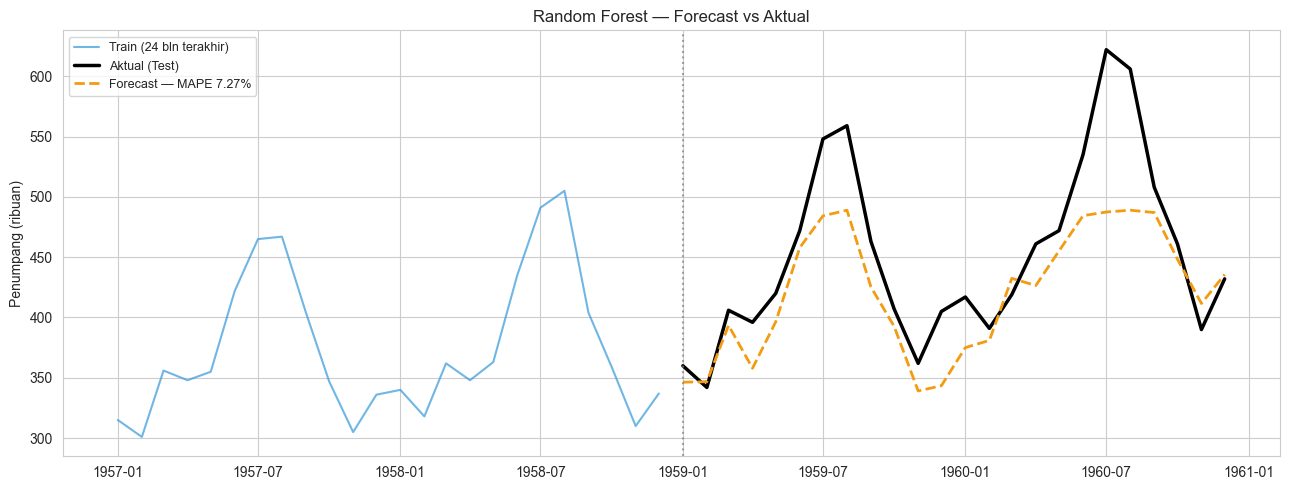

MAPE Random Forest: 7.27%


In [15]:
# Train/test split pada df_feat (temporal)
fitur_kolom = [c for c in df_feat.columns if c != 'target']
X = df_feat[fitur_kolom]
y = df_feat['target']

split_idx   = len(df_feat) - n_test
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

# ── Model 4: Random Forest ────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
fc_rf = rf.predict(X_test)

print("\n✅ Random Forest selesai!")
mape_rf = plot_forecast(train, test, fc_rf, 'Random Forest', '#f39c12')
print(f"MAPE Random Forest: {mape_rf:.2f}%")

✅ XGBoost selesai!


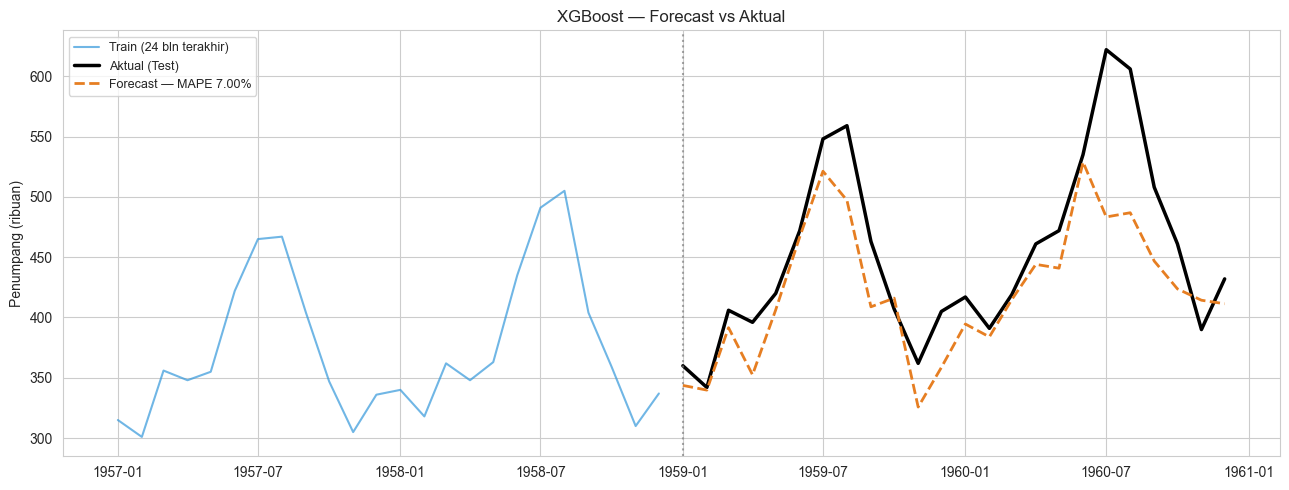

MAPE XGBoost: 7.00%


In [16]:
# ── Model 5: XGBoost ─────────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.7,
    max_depth=5,
    subsample=0.5,
    random_state=42,
    verbosity=0,
)
xgb.fit(X_train, y_train)
fc_xgb = xgb.predict(X_test)

print("✅ XGBoost selesai!")
mape_xgb = plot_forecast(train, test, fc_xgb, 'XGBoost', '#e67e22')
print(f"MAPE XGBoost: {mape_xgb:.2f}%")

---

## BAGIAN 7: Evaluasi & Perbandingan Model

### Metrik Evaluasi Forecasting

| Metrik | Formula | Interpretasi |
|--------|---------|--------------|
| **MAE** | mean(|y − ŷ|) | Rata-rata error absolut dalam satuan asli |
| **RMSE** | √mean((y − ŷ)²) | Penalti lebih besar untuk error besar |
| **MAPE** | mean(\|y − ŷ\| / y) × 100% | Error relatif dalam persen — mudah diinterpretasikan |

```
Perbandingan MAE vs RMSE vs MAPE:

  MAE  : 50 → rata-rata meleset 50 penumpang
  RMSE : 65 → ada beberapa error besar yang "menghukum" lebih
  MAPE : 8% → rata-rata meleset 8% dari nilai aktual
         ↑
         Paling mudah dijelaskan ke stakeholder non-teknis
```

In [17]:
def hitung_metrik(y_true, y_pred, nama):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': nama, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE (%)': round(mape, 2)}

# Evaluasi semua model
df_eval = pd.DataFrame([
    hitung_metrik(test, fc_arima,  'ARIMA(1,1,1)'),
    hitung_metrik(test, fc_sarima, 'SARIMA(1,1,1)(0,1,1,12)'),
    hitung_metrik(test, fc_auto,   f'Auto-ARIMA {model_auto.order}'),
    hitung_metrik(y_test, fc_rf,   'Random Forest'),
    hitung_metrik(y_test, fc_xgb,  'XGBoost'),
])

print("=" * 65)
print("PERBANDINGAN METRIK — 5 MODEL FORECASTING")
print("=" * 65)
print(df_eval.to_string(index=False))
print("\n📌 MAE & RMSE : makin rendah makin baik (satuan: ribuan penumpang)")
print("   MAPE (%)   : makin rendah makin baik (error relatif dalam persen)")

PERBANDINGAN METRIK — 5 MODEL FORECASTING
                  Model   MAE   RMSE  MAPE (%)
           ARIMA(1,1,1) 93.90 118.64     18.84
SARIMA(1,1,1)(0,1,1,12) 69.90  75.63     15.22
   Auto-ARIMA (2, 0, 0) 43.46  47.23      9.44
          Random Forest 35.63  48.50      7.27
                XGBoost 34.11  47.89      7.00

📌 MAE & RMSE : makin rendah makin baik (satuan: ribuan penumpang)
   MAPE (%)   : makin rendah makin baik (error relatif dalam persen)


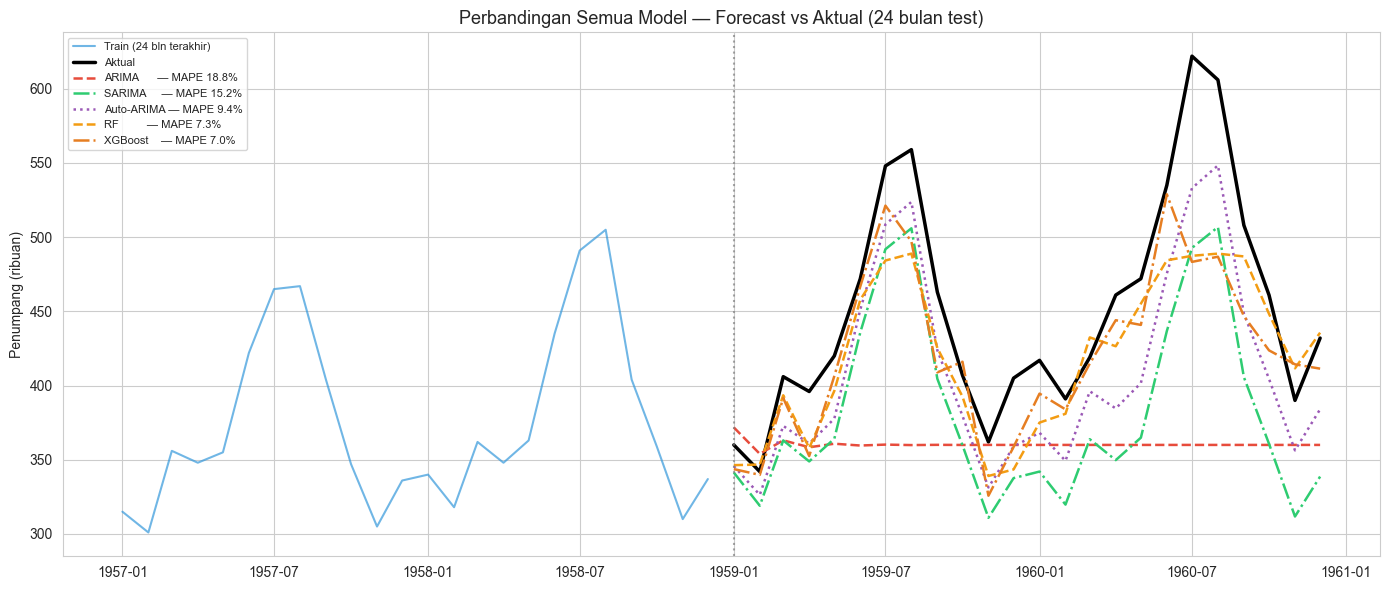

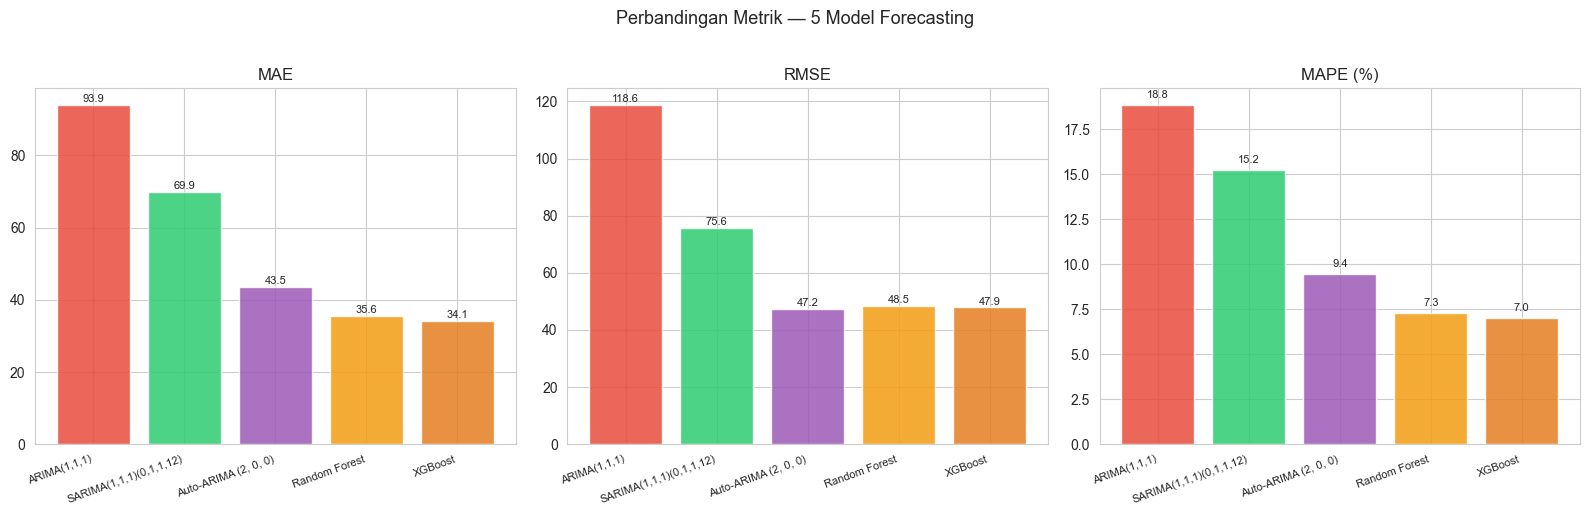


🏆 Model terbaik berdasarkan MAPE: XGBoost (7.00%)


In [18]:
# ── Plot semua forecast dalam satu canvas ────────────────────────────────────
warna_model = {
    'ARIMA':      '#e74c3c',
    'SARIMA':     '#2ecc71',
    'Auto-ARIMA': '#9b59b6',
    'RF':         '#f39c12',
    'XGBoost':    '#e67e22',
}

plt.figure(figsize=(14, 6))
plt.plot(train.iloc[-24:], label='Train (24 bln terakhir)',
         color='#3498db', linewidth=1.5, alpha=0.7)
plt.plot(test, label='Aktual',
         color='black', linewidth=2.5)

model_forecasts = [
    (fc_arima,  f"ARIMA      — MAPE {df_eval.loc[0,'MAPE (%)']:.1f}%", '#e74c3c', '--'),
    (fc_sarima, f"SARIMA     — MAPE {df_eval.loc[1,'MAPE (%)']:.1f}%", '#2ecc71', '-.'),
    (fc_auto,   f"Auto-ARIMA — MAPE {df_eval.loc[2,'MAPE (%)']:.1f}%", '#9b59b6', ':'),
    (fc_rf,     f"RF         — MAPE {df_eval.loc[3,'MAPE (%)']:.1f}%", '#f39c12', '--'),
    (fc_xgb,    f"XGBoost    — MAPE {df_eval.loc[4,'MAPE (%)']:.1f}%", '#e67e22', '-.'),
]
for fc, label, color, ls in model_forecasts:
    plt.plot(pd.Series(np.array(fc), index=test.index),
             label=label, color=color, linewidth=1.8, linestyle=ls)

plt.axvline(test.index[0], color='gray', linestyle=':', alpha=0.7)
plt.title('Perbandingan Semua Model — Forecast vs Aktual (24 bulan test)', fontsize=13)
plt.ylabel('Penumpang (ribuan)')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

# ── Bar chart metrik ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = ['#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#e67e22']

for ax, metrik in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    bars = ax.bar(df_eval['Model'], df_eval[metrik],
                  color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_title(metrik, fontsize=12)
    ax.set_xticklabels(df_eval['Model'], rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, df_eval[metrik]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Perbandingan Metrik — 5 Model Forecasting', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Cetak pemenang
best_idx = df_eval['MAPE (%)'].idxmin()
print(f"\n🏆 Model terbaik berdasarkan MAPE: {df_eval.loc[best_idx, 'Model']} "
      f"({df_eval.loc[best_idx, 'MAPE (%)']:.2f}%)")

---

## ✏️ Latihan Mandiri

Kerjakan soal berikut menggunakan **dataset timeseries tim kamu sendiri**.

> Dataset harus berupa deret waktu yang diukur secara berkala (harian/mingguan/bulanan).  
> Contoh: data penjualan, suhu, pengunjung website, konsumsi listrik, dll.

In [ ]:
# LATIHAN 1: Load & Eksplorasi Data Timeseries Tim
# 1. Load dataset tim kamu (pastikan ada kolom tanggal/waktu)
# 2. Set kolom tanggal sebagai DatetimeIndex
# 3. Plot deret waktu lengkap
# 4. Buat bar chart rata-rata per periode (per bulan / per hari dalam seminggu)
# 5. Identifikasi secara visual: apakah ada trend? ada seasonality?

# Tulis kode di sini:


In [ ]:
# LATIHAN 2: Dekomposisi & ADF Test
# 1. Dekomposisi data tim dengan seasonal_decompose
#    - Tentukan: additive atau multiplicative? Berikan alasannya
#    - Pilih period yang sesuai (7 untuk mingguan, 12 untuk bulanan-tahunan, dst)
# 2. Jalankan ADF Test pada data asli
# 3. Jika tidak stasioner, lakukan differencing hingga stasioner
# 4. Tampilkan ADF Test setelah setiap transformasi

# Tulis kode di sini:


In [ ]:
# LATIHAN 3 (Tantangan): Forecast & Evaluasi
# 1. Buat train/test split temporal (80% train, 20% test)
# 2. Latih SARIMA pada data tim:
#    - Plot ACF & PACF untuk menentukan p, q, P, Q
#    - Fit model SARIMA dan forecast pada periode test
# 3. Latih Random Forest dengan feature engineering lag + rolling:
#    - Gunakan lag yang masuk akal untuk data timmu
#    - Evaluasi dengan MAE, RMSE, dan MAPE
# 4. Visualisasi forecast kedua model vs aktual dalam 1 plot
# 5. Tulis 3–5 kalimat analisis:
#    - Model mana yang lebih baik dan mengapa?
#    - Apakah seasonality terdeteksi dengan baik?
#    - Apa interpretasi bisnis dari pola yang ditemukan?

# Tulis kode dan analisis di sini:


---

## 📝 Ringkasan Pertemuan 12

```
TIME SERIES ANALYSIS — ALUR LENGKAP

DATA TIMESERIES (berurutan waktu)
    ↓
[P12] Eksplorasi & Dekomposisi
        ├── Plot deret waktu → identifikasi trend & seasonality
        ├── seasonal_decompose(model='additive'/'multiplicative')
        └── Rata-rata per periode → pola musiman

    ↓
[P12] Uji Stasioneritas
        ├── ADF Test → p-value ≤ 0.05 = stasioner
        ├── Log transform → stabilkan variansi
        └── Differencing → hilangkan trend & seasonality

    ↓
[P12] Pilih & Latih Model (train/test split TEMPORAL)
        ├── ARIMA(p,d,q)              → statistik, parameter manual
        ├── SARIMA(p,d,q)(P,D,Q,s)    → statistik + seasonal
        ├── Auto-ARIMA                → otomatis pilih parameter
        ├── Random Forest             → ML, perlu lag features
        └── XGBoost                   → ML, gradient boosting

    ↓
[P12] Visualisasi: Forecast vs Aktual (setiap model)
    ↓
[P12] Evaluasi & Bandingkan
        ├── MAE   → rata-rata error absolut
        ├── RMSE  → penalti error besar
        └── MAPE  → error relatif (%)
```

### Perbandingan 5 Model

| Model | Tipe | Perlu Stasioner? | Seasonal? | Kelebihan |
|-------|------|-----------------|-----------|-----------|
| **ARIMA** | Statistik | Ya (manual) | Tidak | Interpretasi mudah |
| **SARIMA** | Statistik | Ya (manual) | ✅ | Tangkap pola musiman |
| **Auto-ARIMA** | Statistik | Otomatis | ✅ | Tidak perlu tuning manual |
| **Random Forest** | ML | Tidak | Via lag_12 | Non-linear, robust |
| **XGBoost** | ML | Tidak | Via lag_12 | Performa tinggi, cepat |

---

**Pertemuan berikutnya: Streamlit — Membangun ML App Interaktif** 🚀